In [ ]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm

import jax.random as jr
import matplotlib.pyplot as plt
import jax
import diffrax
import jax.numpy as jnp

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'times'

from SDE_envs import DoubleWell, LotkaVolterra, VanDerPolOscillator, RosslerAttractor, Lorenz96, SPDE_1D, SPDE_2D
from data_generator import generate_data
colormap = cm.Set3
color_dict = {"KM-SR":(np.float64(0.20196078431372547),
 np.float64(0.5862745098039216),
 np.float64(0.1901960784313726),
 np.float64(1.0)), "GP-ODE":(np.float64(0.9921568627450981),
 np.float64(0.8058823529411765),
 np.float64(0.1843137254901961),
 np.float64(1.0)), "GP-SDE":colormap(0.4), "GP-SDE-MS":(0.7, 0.2, 0.8, 1.0), "GP-ODE-MS":"brown"}


In [ ]:
def compute_average_mse(dataframe):
    drift_data = []
    for column in dataframe.columns:
        if "drift" in column:
            drift_data.extend(dataframe[column])

    diffusion_data = []
    for column in dataframe.columns:
        if "diffusion" in column:
            diffusion_data.extend(dataframe[column])
    
    drift_mean, drift_std = np.mean(drift_data), np.std(drift_data)
    
    if diffusion_data:
        diffusion_mean, diffusion_std = np.mean(diffusion_data), np.std(diffusion_data)
    else:
        diffusion_mean, diffusion_std = None, None

    return drift_mean, drift_std, diffusion_mean, diffusion_std
    
def print_average_mse(dataframe):
    drift_mean, drift_std, diffusion_mean, diffusion_std = compute_average_mse(dataframe)
    drift_str = f"{drift_mean:.4f} ± {drift_std:.4f}"
    diffusion_str = f"{diffusion_mean:.4f} ± {diffusion_std:.4f}" if diffusion_mean is not None else None
    return drift_str, diffusion_str


def compute_average_mse_per_var(dataframe):
    drift_stats = {}
    diffusion_stats = {}
    
    for column in dataframe.columns:
        if "drift" in column:
            values = dataframe[column]
            drift_stats[column] = f"{np.mean(values):.4f} ± {np.std(values):.4f}"
        elif "diffusion" in column:
            values = dataframe[column]
            diffusion_stats[column] = f"{np.mean(values):.4f} ± {np.std(values):.4f}"
    
    return drift_stats, diffusion_stats

# Main results

In [5]:
KM_DW_AD = pd.read_csv("../data/KM_SR/DW_additive.csv")
KM_DW_AD_correct = [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
KM_DW_LI = pd.read_csv("../data/KM_SR/DW_linear.csv")
KM_DW_LI_correct = [[1, 1, 1, 0, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
KM_DW_NL = pd.read_csv("../data/KM_SR/DW_nonlinear.csv")
KM_DW_NL_correct = [[0, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]

SGP_DW_AD = pd.read_csv("../data/GP_SDE/DW_additive.csv")
SGP_DW_AD_correct = [[0, 1, 1, 1, 1, 1, 1, 0, 1, 1], [1, 0, 0, 1, 1, 1, 1, 1, 1, 1]]
SGP_DW_LI = pd.read_csv("../data/GP_SDE/DW_linear.csv")
SGP_DW_LI_correct = [[1, 1, 1, 1, 1, 0, 1, 1, 1, 1], [0, 1, 1, 0, 1, 1, 1, 0, 0, 0]]
SGP_DW_NL = pd.read_csv("../data/GP_SDE/DW_nonlinear.csv")
SGP_DW_NL_correct = [[1, 1, 1, 0, 1, 0, 0, 0, 1, 1], [1, 1, 1, 1, 0, 1, 1, 0, 1, 1]]

OGP_DW_AD = pd.read_csv("../data/GP_ODE/DW_additive.csv")
OGP_DW_AD_correct = [[1, 1, 1, 0, 1, 1, 1, 1, 1, 1]]
OGP_DW_LI = pd.read_csv("../data/GP_ODE/DW_linear.csv")
OGP_DW_LI_correct = [[1, 0, 0, 0, 1, 0, 0, 1, 1, 1]]
OGP_DW_NL = pd.read_csv("../data/GP_ODE/DW_nonlinear.csv")
OGP_DW_NL_correct = [[1, 0, 0, 0, 1, 0, 1, 1, 0, 1]]

KM_vdP = pd.read_csv("../data/KM_SR/vdPol.csv")
KM_vdP_correct = [[2, 2, 2, 2, 2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]
KM_Ros = pd.read_csv("../data/KM_SR/Rossler.csv")
KM_Ros_correct = [[3, 3, 2, 3, 3, 3, 3, 3, 3, 3], [1, 1, 1, 1, 1, 1, 1, 1, 1, 2]]

SGP_vdP = pd.read_csv("../data/GP_SDE/vdPol.csv")
SGP_vdP_correct = [[2, 2, 1, 2, 2, 2, 2, 2, 2, 2], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
SGP_Ros = pd.read_csv("../data/GP_SDE/Rossler.csv")
SGP_Ros_correct = [[3, 3, 3, 3, 3, 3, 3, 3, 3, 3], [3, 2, 2, 2, 2, 3, 2, 2, 2, 2]]

OGP_vdP = pd.read_csv("../data/GP_ODE/vdPol.csv")
OGP_vdP_correct = [[2, 2, 2, 2, 1, 2, 2, 2, 2, 1]]
OGP_Ros = pd.read_csv("../data/GP_ODE/Rossler.csv")
OGP_Ros_correct = [[3, 3, 3, 1, 3, 3, 3, 2, 3, 2]]

KM_Lo5 = pd.read_csv("../data/KM_SR/Lorenz_5.csv")
KM_Lo5_correct = [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
KM_Lo10 = pd.read_csv("../data/KM_SR/Lorenz_10.csv")
KM_Lo10_correct = [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
KM_Lo20 = pd.read_csv("../data/KM_SR/Lorenz_20.csv")
KM_Lo20_correct = [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

SGP_Lo5 = pd.read_csv("../data/GP_SDE/Lorenz_5.csv")
SGP_Lo5_correct = [[1, 1, 1, 1, 1, 1, 1, 1, 1, 0], [1, 1, 1, 1, 0, 1, 0, 0, 1, 1]]
SGP_Lo10 = pd.read_csv("../data/GP_SDE/Lorenz_10.csv")
SGP_Lo10_correct = [[1, 0, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
SGP_Lo20 = pd.read_csv("../data/GP_SDE/Lorenz_20.csv")
SGP_Lo20_correct = [[1, 1, 0, 1, 1, 1, 0, 1, 0, 1], [1, 0, 0, 0, 1, 1, 1, 1, 1, 1]]

OGP_Lo5 = pd.read_csv("../data/GP_ODE/Lorenz_5.csv")
OGP_Lo5_correct = [[1, 1, 1, 1, 1, 1, 0, 1, 1, 1]]
OGP_Lo10 = pd.read_csv("../data/GP_ODE/Lorenz_10.csv")
OGP_Lo10_correct = [[1, 1, 1, 1, 1, 1, 1, 1, 0, 0]]
OGP_Lo20 = pd.read_csv("../data/GP_ODE/Lorenz_20.csv")
OGP_Lo20_correct = [[1, 0, 1, 1, 1, 0, 1, 1, 1, 1]]

KM_LV_002 = pd.read_csv("../data/KM_SR/LV_0.02.csv")
KM_LV_002_correct = [[2, 2, 1, 1, 1, 2, 2, 2, 2, 1], [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]
KM_LV_02 = pd.read_csv("../data/KM_SR/LV_0.2.csv")
KM_LV_02_correct = [[1, 2, 2, 2, 2, 1, 1, 1, 1, 2], [2, 1, 1, 2, 1, 1, 1, 1, 1, 1]]
KM_LV_05 = pd.read_csv("../data/KM_SR/LV_0.5.csv")
KM_LV_05_correct = [[2, 1, 2, 1, 2, 1, 2, 0, 1, 0], [2, 1, 1, 1, 2, 1, 1, 1, 2, 1]]

SGP_LV_002 = pd.read_csv("../data/GP_SDE/LV_0.02.csv")
SGP_LV_002_correct = [[2, 2, 2, 2, 2, 2, 2, 2, 2, 2], [0, 1, 0, 1, 1, 0, 1, 1, 0, 0]]
SGP_LV_02 = pd.read_csv("../data/GP_SDE/LV_0.2.csv")
SGP_LV_02_correct = [[2, 2, 2, 2, 2, 2, 2, 1, 2, 2], [1, 0, 1, 1, 0, 1, 0, 1, 1, 0]]
SGP_LV_05 = pd.read_csv("../data/GP_SDE/LV_0.5.csv")
SGP_LV_05_correct = [[2, 2, 1, 2, 1, 2, 1, 1, 1, 1], [1, 1, 0, 1, 1, 0, 1, 0, 1, 1]]

OGP_LV_002 = pd.read_csv("../data/GP_ODE/LV_0.02.csv")
OGP_LV_002_correct = [[2, 2, 2, 2, 2, 1, 2, 2, 1, 0]]
OGP_LV_02 = pd.read_csv("../data/GP_ODE/LV_0.2.csv")
OGP_LV_02_correct = [[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]
OGP_LV_05 = pd.read_csv("../data/GP_ODE/LV_0.5.csv")
OGP_LV_05_correct = [[2, 1, 1, 1, 0, 1, 1, 2, 0, 0]]

SGP_LV_02_MS = pd.read_csv("../data/GP_SDE/LV_MS_0.2.csv")
SGP_LV_02_MS_correct = [[2, 2, 2, 1, 1, 2, 2, 1, 2, 2], [2, 2, 2, 1, 2, 2, 2, 2, 2, 2]]
SGP_LV_05_MS = pd.read_csv("../data/GP_SDE/LV_MS_0.5.csv")
SGP_LV_05_MS_correct = [[2, 2, 1, 2, 2, 2, 2, 2, 2, 2], [1, 1, 2, 2, 1, 2, 2, 1, 1, 1]]

OGP_LV_02_MS = pd.read_csv("../data/GP_ODE/LV_MS_0.2.csv")
OGP_LV_02_MS_correct = [[2, 2, 2, 1, 2, 1, 2, 1, 1, 1]]
OGP_LV_05_MS = pd.read_csv("../data/GP_ODE/LV_MS_0.5.csv")
OGP_LV_05_MS_correct = [[1, 1, 1, 1, 0, 2, 1, 1, 1, 0]]

excess data in 'kern' subtable: 6 bytes


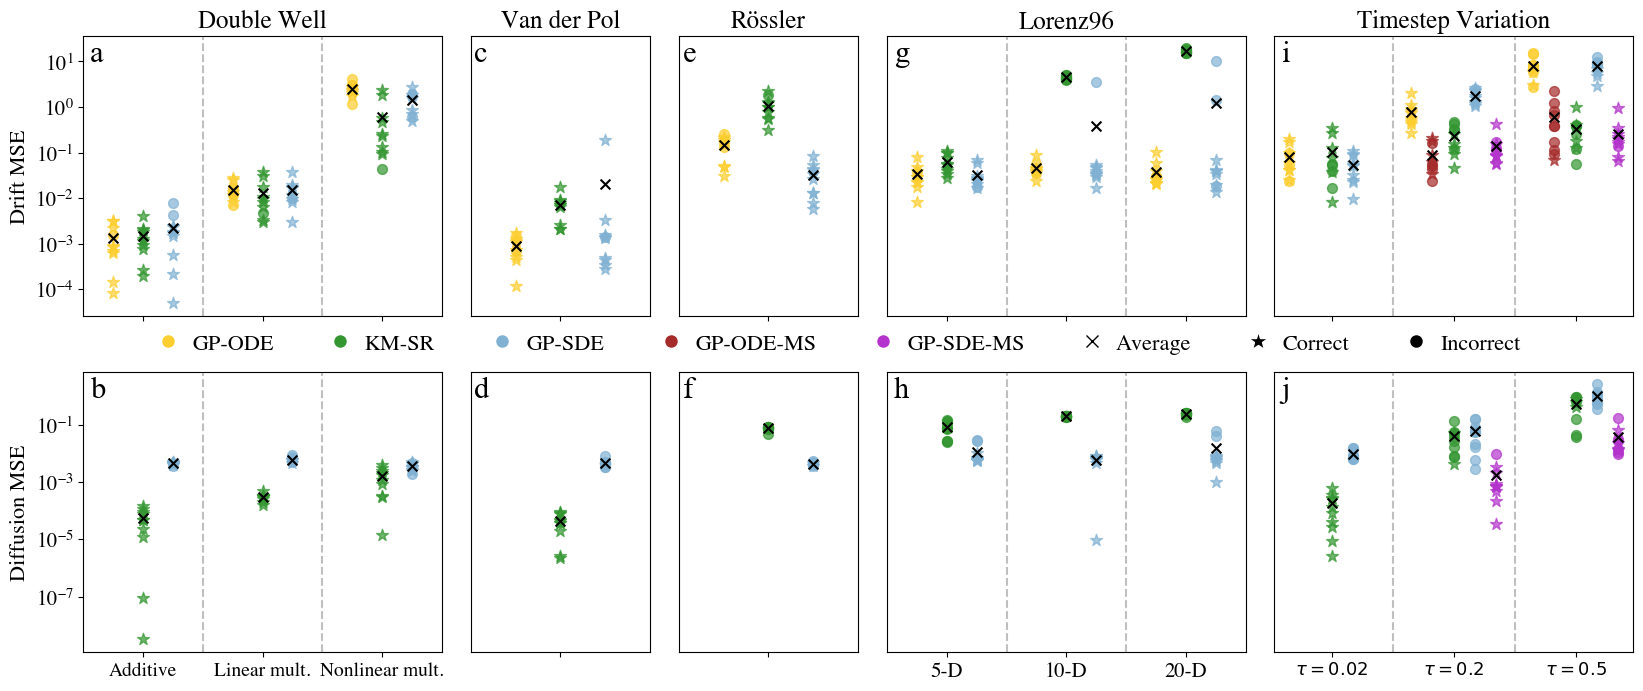

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey='row', gridspec_kw={'width_ratios': [1, 0.5, 0.5, 1, 1], 'wspace': 0.1, 'hspace': 0.2})

# ============ COLUMN 1: DOUBLE WELL ============
dw_datasets = [
    ('Additive diffusion', KM_DW_AD, SGP_DW_AD, OGP_DW_AD, KM_DW_AD_correct, SGP_DW_AD_correct, OGP_DW_AD_correct),
    ('Linear multiplicative diffusion', KM_DW_LI, SGP_DW_LI, OGP_DW_LI, KM_DW_LI_correct, SGP_DW_LI_correct, OGP_DW_LI_correct),
    ('Non-linear multiplicative diffusion', KM_DW_NL, SGP_DW_NL, OGP_DW_NL, KM_DW_NL_correct, SGP_DW_NL_correct, OGP_DW_NL_correct)
]

# Double well - Drift plot (top row, first column)
ax = axes[0, 0]
dw_names = [title for title, _, _, _, _, _, _ in dw_datasets]
dw_positions = np.arange(len(dw_names))
width = 0.25

for idx, (title, km_data, sgp_data, ogp_data, km_correct, sgp_correct, ogp_correct) in enumerate(dw_datasets):
    km_values = km_data['x0_test_drift_mse']
    sgp_values = sgp_data['x0_test_drift_mse']
    ogp_values = ogp_data['x0_test_drift_mse']
    
    x_ogp = np.full(len(ogp_values), dw_positions[idx] - width)
    x_km = np.full(len(km_values), dw_positions[idx])
    x_sgp = np.full(len(sgp_values), dw_positions[idx] + width)
    
    # Plot with different markers based on correctness (star for correct=1, circle for correct=0)
    for i, (ogp_val, ogp_corr) in enumerate(zip(ogp_values, ogp_correct[0])):
        marker = '*' if ogp_corr == 1 else 'o'
        ax.scatter(x_ogp[i], ogp_val, color=color_dict["GP-ODE"], s=50 + 30*(ogp_corr == 1), alpha=0.7, marker=marker)
    ax.scatter(x_ogp[0], np.mean(ogp_values), color='black', s=50, marker='x')
    
    for i, (km_val, km_corr) in enumerate(zip(km_values, km_correct[0])):
        marker = '*' if km_corr == 1 else 'o'
        ax.scatter(x_km[i], km_val, color=color_dict["KM-SR"], s=50 + 30*(km_corr == 1), alpha=0.7, marker=marker)
    ax.scatter(x_km[0], np.mean(km_values), color='black', s=50, marker='x')
    
    for i, (sgp_val, sgp_corr) in enumerate(zip(sgp_values, sgp_correct[0])):
        marker = '*' if sgp_corr == 1 else 'o'
        ax.scatter(x_sgp[i], sgp_val, color=color_dict["GP-SDE"], s=50 + 30*(sgp_corr == 1), alpha=0.7, marker=marker)
    ax.scatter(x_sgp[0], np.mean(sgp_values), color='black', s=50, marker='x')

ax.set_xticks(dw_positions)
ax.set_xticklabels(['','',''], fontsize=14)
ax.set_xlim(dw_positions[0]-width*2, dw_positions[-1]+width*2)
ax.set_ylabel('Drift MSE', fontsize=16)
ax.set_title('Double Well', fontsize=18)
ax.tick_params(axis='y', labelsize=15)

ax.text(0.02, 0.91, 'a', transform=ax.transAxes, fontsize=22, font='Times New Roman')

for i in range(1, len(dw_datasets)):
    ax.axvline(x=dw_positions[i] - 0.5, color='gray', linestyle='--', alpha=0.5)

# Double well - Diffusion plot (bottom row, first column)
ax = axes[1, 0]
width=0.5
for idx, (title, km_data, sgp_data, ogp_data, km_correct, sgp_correct, ogp_correct) in enumerate(dw_datasets):
    km_values = km_data['x0_test_diffusion_mse']
    sgp_values = sgp_data['x0_test_diffusion_mse']
    
    x_km = np.full(len(km_values), dw_positions[idx])
    x_sgp = np.full(len(sgp_values), dw_positions[idx] + width/2)
    
    # Plot with different markers based on correctness (star for correct=1, circle for correct=0)
    # Use diffusion correctness (index 1) for diffusion plot
    for i, (km_val, km_corr) in enumerate(zip(km_values, km_correct[1])):
        marker = '*' if km_corr == 1 else 'o'
        ax.scatter(x_km[i], km_val, color=color_dict["KM-SR"], s=50 + 30*(km_corr == 1), alpha=0.7, marker=marker)
    ax.scatter(x_km[0], np.mean(km_values), color='black', s=50, marker='x')
    
    for i, (sgp_val, sgp_corr) in enumerate(zip(sgp_values, sgp_correct[1])):
        marker = '*' if sgp_corr == 1 else 'o'
        ax.scatter(x_sgp[i], sgp_val, color=color_dict["GP-SDE"], s=50 + 30*(sgp_corr == 1), alpha=0.7, marker=marker)
    ax.scatter(x_sgp[0], np.mean(sgp_values), color='black', s=50, marker='x')

ax.set_xticks(dw_positions)
ax.set_xticklabels(['Additive', 'Linear mult.', 'Nonlinear mult.'], fontsize=14)
ax.set_xlim(dw_positions[0]-width, dw_positions[-1]+width)
ax.tick_params(axis='y', labelsize=15)
ax.set_ylabel('Diffusion MSE', fontsize=16)

ax.text(0.02, 0.91, 'b', transform=ax.transAxes, fontsize=22, font='Times New Roman')

for i in range(1, len(dw_datasets)):
    ax.axvline(x=dw_positions[i] - 0.5, color='gray', linestyle='--', alpha=0.5)

# ============ COLUMN 2: VAN DER POL ============
# Van der Pol - Drift plot (top row, second column)
ax = axes[0, 1]
width=0.25

km_values = KM_vdP[[col for col in KM_vdP.columns if 'drift_mse' in col]].mean(axis=1)
sgp_values = SGP_vdP[[col for col in SGP_vdP.columns if 'drift_mse' in col]].mean(axis=1)
ogp_values = OGP_vdP[[col for col in OGP_vdP.columns if 'drift_mse' in col]].mean(axis=1)

x_ogp = np.full(len(ogp_values), 0 - width)
x_km = np.full(len(km_values), 0)
x_sgp = np.full(len(sgp_values), 0 + width)

# Plot with correctness indicators
for i, (ogp_val, ogp_corr) in enumerate(zip(ogp_values, OGP_vdP_correct[0])):
    marker = '*' if ogp_corr == 2 else 'o'
    ax.scatter(x_ogp[i], ogp_val, color=color_dict["GP-ODE"], s=50 + 30*(ogp_corr == 2), alpha=0.7, marker=marker)
ax.scatter(x_ogp[0], np.mean(ogp_values), color='black', s=50, marker='x')

for i, (km_val, km_corr) in enumerate(zip(km_values, KM_vdP_correct[0])):
    marker = '*' if km_corr == 2 else 'o'
    ax.scatter(x_km[i], km_val, color=color_dict["KM-SR"], s=50 + 30*(km_corr == 2), alpha=0.7, marker=marker)
ax.scatter(x_km[0], np.mean(km_values), color='black', s=50, marker='x')

for i, (sgp_val, sgp_corr) in enumerate(zip(sgp_values, SGP_vdP_correct[0])):
    marker = '*' if sgp_corr == 2 else 'o'
    ax.scatter(x_sgp[i], sgp_val, color=color_dict["GP-SDE"], s=50 + 30*(sgp_corr == 2), alpha=0.7, marker=marker)
ax.scatter(x_sgp[0], np.mean(sgp_values), color='black', s=50, marker='x')

ax.set_xticks([0])
ax.set_xticklabels([''], fontsize=13)
ax.set_xlim(-width*2, width*2)
ax.set_title('Van der Pol', fontsize=18)

ax.text(0.02, 0.91, 'c', transform=ax.transAxes, fontsize=22, font='Times New Roman')

# Van der Pol - Diffusion plot (bottom row, second column)
ax = axes[1, 1]
width=0.5

km_values = KM_vdP[[col for col in KM_vdP.columns if 'diffusion_mse' in col]].mean(axis=1)
sgp_values = SGP_vdP[[col for col in SGP_vdP.columns if 'diffusion_mse' in col]].mean(axis=1)

x_km = np.full(len(km_values), 0)
x_sgp = np.full(len(sgp_values), 0 + width/2)

# Plot with correctness indicators for diffusion
for i, (km_val, km_corr) in enumerate(zip(km_values, KM_vdP_correct[1])):
    marker = '*' if km_corr == 2 else 'o'
    ax.scatter(x_km[i], km_val, color=color_dict["KM-SR"], s=50 + 30*(km_corr == 2), alpha=0.7, marker=marker)
ax.scatter(x_km[0], np.mean(km_values), color='black', s=50, marker='x')

for i, (sgp_val, sgp_corr) in enumerate(zip(sgp_values, SGP_vdP_correct[1])):
    marker = '*' if sgp_corr == 2 else 'o'
    ax.scatter(x_sgp[i], sgp_val, color=color_dict["GP-SDE"], s=50 + 30*(sgp_corr == 2), alpha=0.7, marker=marker)
ax.scatter(x_sgp[0], np.mean(sgp_values), color='black', s=50, marker='x')

ax.set_xticks([0])
ax.set_xticklabels([''], fontsize=13)
ax.set_xlim(-width, width)

ax.text(0.02, 0.91, 'd', transform=ax.transAxes, fontsize=22, font='Times New Roman')

# ============ COLUMN 3: RÖSSLER ============
# Rössler - Drift plot (top row, third column)
ax = axes[0, 2]
width=0.25

km_values = KM_Ros[[col for col in KM_Ros.columns if 'drift_mse' in col]].mean(axis=1)
sgp_values = SGP_Ros[[col for col in SGP_Ros.columns if 'drift_mse' in col]].mean(axis=1)
ogp_values = OGP_Ros[[col for col in OGP_Ros.columns if 'drift_mse' in col]].mean(axis=1)

x_ogp = np.full(len(ogp_values), 0 - width)
x_km = np.full(len(km_values), 0)
x_sgp = np.full(len(sgp_values), 0 + width)

# Plot with correctness indicators
for i, (ogp_val, ogp_corr) in enumerate(zip(ogp_values, OGP_Ros_correct[0])):
    marker = '*' if ogp_corr == 3 else 'o'
    ax.scatter(x_ogp[i], ogp_val, color=color_dict["GP-ODE"], s=50 + 30*(ogp_corr == 3), alpha=0.7, marker=marker)
ax.scatter(x_ogp[0], np.mean(ogp_values), color='black', s=50, marker='x')

for i, (km_val, km_corr) in enumerate(zip(km_values, KM_Ros_correct[0])):
    marker = '*' if km_corr == 3 else 'o'
    ax.scatter(x_km[i], km_val, color=color_dict["KM-SR"], s=50 + 30*(km_corr == 3), alpha=0.7, marker=marker)
ax.scatter(x_km[0], np.mean(km_values), color='black', s=50, marker='x')

for i, (sgp_val, sgp_corr) in enumerate(zip(sgp_values, SGP_Ros_correct[0])):
    marker = '*' if sgp_corr == 3 else 'o'
    ax.scatter(x_sgp[i], sgp_val, color=color_dict["GP-SDE"], s=50 + 30*(sgp_corr == 3), alpha=0.7, marker=marker)
ax.scatter(x_sgp[0], np.mean(sgp_values), color='black', s=50, marker='x')

ax.set_xticks([0])
ax.set_xticklabels([''], fontsize=13)
ax.set_xlim(-width*2, width*2)
ax.set_title('Rössler', fontsize=18)

ax.text(0.02, 0.91, 'e', transform=ax.transAxes, fontsize=22, font='Times New Roman')

# Rössler - Diffusion plot (bottom row, third column)
ax = axes[1, 2]
width=0.5

km_values = KM_Ros[[col for col in KM_Ros.columns if 'diffusion_mse' in col]].mean(axis=1)
sgp_values = SGP_Ros[[col for col in SGP_Ros.columns if 'diffusion_mse' in col]].mean(axis=1)

x_km = np.full(len(km_values), 0)
x_sgp = np.full(len(sgp_values), 0 + width/2)

# Plot with correctness indicators for diffusion
for i, (km_val, km_corr) in enumerate(zip(km_values, KM_Ros_correct[1])):
    marker = '*' if km_corr == 3 else 'o'
    ax.scatter(x_km[i], km_val, color=color_dict["KM-SR"], s=50 + 30*(km_corr == 3), alpha=0.7, marker=marker)
ax.scatter(x_km[0], np.mean(km_values), color='black', s=50, marker='x')

for i, (sgp_val, sgp_corr) in enumerate(zip(sgp_values, SGP_Ros_correct[1])):
    marker = '*' if sgp_corr == 3 else 'o'
    ax.scatter(x_sgp[i], sgp_val, color=color_dict["GP-SDE"], s=50 + 30*(sgp_corr == 3), alpha=0.7, marker=marker)
ax.scatter(x_sgp[0], np.mean(sgp_values), color='black', s=50, marker='x')

ax.set_xticks([0])
ax.set_xticklabels([''], fontsize=13)
ax.set_xlim(-width, width)

ax.text(0.02, 0.91, 'f', transform=ax.transAxes, fontsize=22, font='Times New Roman')

# ============ COLUMN 4: LORENZ ============
lorenz_datasets = [
    ('Lorenz96 5-D', KM_Lo5, SGP_Lo5, OGP_Lo5, KM_Lo5_correct, SGP_Lo5_correct, OGP_Lo5_correct),
    ('Lorenz96 10-D', KM_Lo10, SGP_Lo10, OGP_Lo10, KM_Lo10_correct, SGP_Lo10_correct, OGP_Lo10_correct),
    ('Lorenz96 20-D', KM_Lo20, SGP_Lo20, OGP_Lo20, KM_Lo20_correct, SGP_Lo20_correct, OGP_Lo20_correct)
]

# Lorenz - Drift plot (top row, fourth column)
ax = axes[0, 3]
lorenz_names = ['5-D', '10-D', '20-D']
lorenz_positions = np.arange(len(lorenz_names))
width=0.25

for idx, (title, km_data, sgp_data, ogp_data, km_correct, sgp_correct, ogp_correct) in enumerate(lorenz_datasets):
    km_values = km_data[[col for col in km_data.columns if 'drift_mse' in col]].mean(axis=1)
    sgp_values = sgp_data[[col for col in sgp_data.columns if 'drift_mse' in col]].mean(axis=1)
    ogp_values = ogp_data[[col for col in ogp_data.columns if 'drift_mse' in col]].mean(axis=1)
    
    x_ogp = np.full(len(ogp_values), lorenz_positions[idx] - width)
    x_km = np.full(len(km_values), lorenz_positions[idx])
    x_sgp = np.full(len(sgp_values), lorenz_positions[idx] + width)
    
    # Plot with correctness indicators
    for i, (ogp_val, ogp_corr) in enumerate(zip(ogp_values, ogp_correct[0])):
        marker = '*' if ogp_corr == 1 else 'o'
        ax.scatter(x_ogp[i], ogp_val, color=color_dict["GP-ODE"], s=50 + 30*(ogp_corr == 1), alpha=0.7, marker=marker)
    ax.scatter(x_ogp[0], np.mean(ogp_values), color='black', s=50, marker='x')
    
    for i, (km_val, km_corr) in enumerate(zip(km_values, km_correct[0])):
        marker = '*' if km_corr == 1 else 'o'
        ax.scatter(x_km[i], km_val, color=color_dict["KM-SR"], s=50 + 30*(km_corr == 1), alpha=0.7, marker=marker)
    ax.scatter(x_km[0], np.mean(km_values), color='black', s=50, marker='x')
    
    for i, (sgp_val, sgp_corr) in enumerate(zip(sgp_values, sgp_correct[0])):
        marker = '*' if sgp_corr == 1 else 'o'
        ax.scatter(x_sgp[i], sgp_val, color=color_dict["GP-SDE"], s=50 + 30*(sgp_corr == 1), alpha=0.7, marker=marker)
    ax.scatter(x_sgp[0], np.mean(sgp_values), color='black', s=50, marker='x')

ax.set_xticks(lorenz_positions)
ax.set_xticklabels(['','',''], fontsize=13)
ax.set_xlim(lorenz_positions[0]-width*2, lorenz_positions[-1]+width*2)
ax.set_title('Lorenz96', fontsize=18)

ax.text(0.02, 0.91, 'g', transform=ax.transAxes, fontsize=22, font='Times New Roman')

for i in range(1, len(lorenz_datasets)):
    ax.axvline(x=lorenz_positions[i] - 0.5, color='gray', linestyle='--', alpha=0.5)

# Lorenz - Diffusion plot (bottom row, fourth column)
ax = axes[1, 3]
width=0.5
for idx, (title, km_data, sgp_data, ogp_data, km_correct, sgp_correct, ogp_correct) in enumerate(lorenz_datasets):
    km_values = km_data[[col for col in km_data.columns if 'diffusion_mse' in col]].mean(axis=1)
    sgp_values = sgp_data[[col for col in sgp_data.columns if 'diffusion_mse' in col]].mean(axis=1)
    
    x_km = np.full(len(km_values), lorenz_positions[idx])
    x_sgp = np.full(len(sgp_values), lorenz_positions[idx] + width/2)
    
    # Plot with correctness indicators for diffusion
    for i, (km_val, km_corr) in enumerate(zip(km_values, km_correct[1])):
        marker = '*' if km_corr == 1 else 'o'
        ax.scatter(x_km[i], km_val, color=color_dict["KM-SR"], s=50 + 30*(km_corr == 1), alpha=0.7, marker=marker)
    ax.scatter(x_km[0], np.mean(km_values), color='black', s=50, marker='x')
    
    for i, (sgp_val, sgp_corr) in enumerate(zip(sgp_values, sgp_correct[1])):
        marker = '*' if sgp_corr == 1 else 'o'
        ax.scatter(x_sgp[i], sgp_val, color=color_dict["GP-SDE"], s=50 + 30*(sgp_corr == 1), alpha=0.7, marker=marker)
    ax.scatter(x_sgp[0], np.mean(sgp_values), color='black', s=50, marker='x')

ax.set_xticks(lorenz_positions)
ax.set_xlim(lorenz_positions[0]-width, lorenz_positions[-1]+width)
ax.set_xticklabels(lorenz_names, fontsize=15)

ax.text(0.02, 0.91, 'h', transform=ax.transAxes, fontsize=22, font='Times New Roman')

for i in range(1, len(lorenz_datasets)):
    ax.axvline(x=lorenz_positions[i] - 0.5, color='gray', linestyle='--', alpha=0.5)

# ============ COLUMN 5: TIMESTEP ============
ts_datasets = [
    (r'$\tau=0.02$', KM_LV_002, SGP_LV_002, SGP_LV_05_MS, OGP_LV_002, OGP_LV_02_MS, KM_LV_002_correct, SGP_LV_002_correct, OGP_LV_002_correct, SGP_LV_02_MS_correct, OGP_LV_02_MS_correct),
    (r'$\tau=0.2$', KM_LV_02, SGP_LV_02, SGP_LV_02_MS, OGP_LV_02, OGP_LV_02_MS, KM_LV_02_correct, SGP_LV_02_correct, OGP_LV_02_correct, SGP_LV_02_MS_correct, OGP_LV_02_MS_correct),
    (r'$\tau=0.5$', KM_LV_05, SGP_LV_05, SGP_LV_05_MS, OGP_LV_05, OGP_LV_05_MS, KM_LV_05_correct, SGP_LV_05_correct, OGP_LV_05_correct, SGP_LV_05_MS_correct, OGP_LV_05_MS_correct)
]

# Timestep - Drift plot (top row, fifth column)
ax = axes[0, 4]
ts_names = [r'$\tau=0.02$', r'$\tau=0.2$', r'$\tau=0.5$']
ts_positions = np.arange(len(ts_names))
width=0.35

for idx, (title, km_data, sgp_data, sgp_ms_data, ogp_data, ogp_ms_data, km_correct, sgp_correct, ogp_correct, sgp_ms_correct, ogp_ms_correct) in enumerate(ts_datasets):
    km_values = km_data[[col for col in km_data.columns if 'drift_mse' in col]].mean(axis=1)
    sgp_values = sgp_data[[col for col in sgp_data.columns if 'drift_mse' in col]].mean(axis=1)
    ogp_values = ogp_data[[col for col in ogp_data.columns if 'drift_mse' in col]].mean(axis=1)
    
    x_ogp = np.full(len(ogp_values), ts_positions[idx] - width)
    x_km = np.full(len(km_values), ts_positions[idx])
    x_sgp = np.full(len(sgp_values), ts_positions[idx] + width/2)
    
    # Plot with correctness indicators
    for i, (ogp_val, ogp_corr) in enumerate(zip(ogp_values, ogp_correct[0])):
        marker = '*' if ogp_corr == 2 else 'o'
        ax.scatter(x_ogp[i], ogp_val, color=color_dict["GP-ODE"], s=50 + 30*(ogp_corr == 2), alpha=0.7, marker=marker)
    ax.scatter(x_ogp[0], np.mean(ogp_values), color='black', s=50, marker='x')
    
    for i, (km_val, km_corr) in enumerate(zip(km_values, km_correct[0])):
        marker = '*' if km_corr == 2 else 'o'
        ax.scatter(x_km[i], km_val, color=color_dict["KM-SR"], s=50 + 30*(km_corr == 2), alpha=0.7, marker=marker)
    ax.scatter(x_km[0], np.mean(km_values), color='black', s=50, marker='x')
    
    for i, (sgp_val, sgp_corr) in enumerate(zip(sgp_values, sgp_correct[0])):
        marker = '*' if sgp_corr == 2 else 'o'
        ax.scatter(x_sgp[i], sgp_val, color=color_dict["GP-SDE"], s=50 + 30*(sgp_corr == 2), alpha=0.7, marker=marker)
    ax.scatter(x_sgp[0], np.mean(sgp_values), color='black', s=50, marker='x')

    if idx > 0:
        sgp_ms_values = sgp_ms_data[[col for col in sgp_ms_data.columns if 'drift_mse' in col]].mean(axis=1)
        x_sgp_ms = np.full(len(sgp_ms_values), ts_positions[idx] + width)
        for i, (sgp_val, sgp_corr) in enumerate(zip(sgp_ms_values, sgp_ms_correct[0])):
            marker = '*' if sgp_corr == 2 else 'o'
            ax.scatter(x_sgp_ms[i], sgp_val, color=color_dict["GP-SDE-MS"], s=50 + 30*(sgp_corr == 2), alpha=0.7, marker=marker)
        ax.scatter(x_sgp_ms[0], np.mean(sgp_ms_values), color='black', s=50, marker='x')

        ogp_ms_values = ogp_ms_data[[col for col in ogp_ms_data.columns if 'drift_mse' in col]].mean(axis=1)
        x_ogp_ms = np.full(len(ogp_ms_values), ts_positions[idx] - width/2)
        for i, (ogp_val, ogp_corr) in enumerate(zip(ogp_ms_values, ogp_ms_correct[0])):
            marker = '*' if ogp_corr == 2 else 'o'
            ax.scatter(x_ogp_ms[i], ogp_val, color=color_dict["GP-ODE-MS"], s=50 + 30*(ogp_corr == 2), alpha=0.7, marker=marker)
        ax.scatter(x_ogp_ms[0], np.mean(ogp_ms_values), color='black', s=50, marker='x')

ax.set_xticks(ts_positions)
ax.set_xticklabels(['','',''], fontsize=13)
ax.set_xlim(ts_positions[0]-width*1.35, ts_positions[-1]+width*1.35)
ax.set_title('Timestep Variation', fontsize=18)

ax.text(0.02, 0.91, 'i', transform=ax.transAxes, fontsize=22, font='Times New Roman')

for i in range(1, len(ts_datasets)):
    ax.axvline(x=ts_positions[i] - 0.5, color='gray', linestyle='--', alpha=0.5)

# Timestep - Diffusion plot (bottom row, fifth column)
ax = axes[1, 4]
width=0.35
for idx, (title, km_data, sgp_data, sgp_ms_data, ogp_data, ogp_ms_data, km_correct, sgp_correct, ogp_correct, sgp_ms_correct, ogp_ms_correct) in enumerate(ts_datasets):
    km_values = km_data[[col for col in km_data.columns if 'diffusion_mse' in col]].mean(axis=1)
    sgp_values = sgp_data[[col for col in sgp_data.columns if 'diffusion_mse' in col]].mean(axis=1)
    
    x_km = np.full(len(km_values), ts_positions[idx])
    x_sgp = np.full(len(sgp_values), ts_positions[idx] + width/2)
    
    # Plot with correctness indicators for diffusion
    for i, (km_val, km_corr) in enumerate(zip(km_values, km_correct[1])):
        marker = '*' if km_corr == 2 else 'o'
        ax.scatter(x_km[i], km_val, color=color_dict["KM-SR"], s=50 + 30*(km_corr == 2), alpha=0.7, marker=marker)
    ax.scatter(x_km[0], np.mean(km_values), color='black', s=50, marker='x')
    
    for i, (sgp_val, sgp_corr) in enumerate(zip(sgp_values, sgp_correct[1])):
        marker = '*' if sgp_corr == 2 else 'o'
        ax.scatter(x_sgp[i], sgp_val, color=color_dict["GP-SDE"], s=50 + 30*(sgp_corr == 2), alpha=0.7, marker=marker)
    ax.scatter(x_sgp[0], np.mean(sgp_values), color='black', s=50, marker='x')

    if idx > 0:
        sgp_ms_values = sgp_ms_data[[col for col in sgp_ms_data.columns if 'diffusion_mse' in col]].mean(axis=1)
        x_sgp_ms = np.full(len(sgp_ms_values), ts_positions[idx] + width)
        for i, (sgp_val, sgp_corr) in enumerate(zip(sgp_ms_values, sgp_ms_correct[1])):
            marker = '*' if sgp_corr == 2 else 'o'
            ax.scatter(x_sgp_ms[i], sgp_val, color=color_dict["GP-SDE-MS"], s=50 + 30*(sgp_corr == 2), alpha=0.7, marker=marker)
        ax.scatter(x_sgp_ms[0], np.mean(sgp_ms_values), color='black', s=50, marker='x')

ax.set_xticks(ts_positions)
ax.set_xlim(ts_positions[0]-width*1.35, ts_positions[-1]+width*1.35)
ax.set_xticklabels(ts_names, fontsize=13)
ax.text(0.02, 0.91, 'j', transform=ax.transAxes, fontsize=22, font='Times New Roman')

for i in range(1, len(ts_datasets)):
    ax.axvline(x=ts_positions[i] - 0.5, color='gray', linestyle='--', alpha=0.5)

# Create figure-level legend with 7 columns positioned between the rows
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict["GP-ODE"], markersize=10, label='GP-ODE'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict["KM-SR"], markersize=10, label='KM-SR'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict["GP-SDE"], markersize=10, label='GP-SDE'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict["GP-ODE-MS"], markersize=10, label='GP-ODE-MS'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict["GP-SDE-MS"], markersize=10, label='GP-SDE-MS'),
    plt.Line2D([0], [0], marker='x', color='w', markerfacecolor='black', markersize=8, label='Average', markeredgecolor='black'),
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='black', markersize=15, label='Correct'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Incorrect'),
]
fig.legend(handles=handles, loc='center', bbox_to_anchor=(0.5, 0.495), ncol=8, fontsize=16, frameon=False, handletextpad=0.1)

from matplotlib.ticker import LogLocator, NullLocator, LogFormatter

for row in range(2):
    ax_left = axes[row, 0]
    ax_left.set_yscale('log')
    ax_left.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10/(row+1)))
    ax_left.yaxis.set_minor_locator(NullLocator())

for row in range(2):
    for col in range(1,5):
        ax = axes[row, col]
        ax.tick_params(axis='y', which='both',
                       left=False, labelleft=False)

plt.savefig('../figures/main_result.pdf')
plt.show()

# Rossler simulations

In [8]:
def simulate_ODE(init_state, ts, process_noise_key):

    def drift(t, x, args):
        x0, x1, x2 = x
        dx = jnp.array([-0.999*x1 - 0.999*x2, x0 + 0.196*x1, x2*(x0 - 5.79) + 0.282])
        return dx

    system = diffrax.ODETerm(drift)

    sol = diffrax.diffeqsolve(
        system,
        diffrax.Tsit5(),
        t0=ts[0],
        t1=ts[-1],
        dt0=0.001,
        y0=init_state,
        saveat=diffrax.SaveAt(ts=ts),
        adjoint=diffrax.DirectAdjoint(),
        max_steps = 16**5
    )

    ys = sol.ys
    return ys

def simulate_KM(init_state, ts, process_noise_key):

    def drift(t, x, args):
        x0, x1, x2 = x
        # dx = jnp.array([-1.014*x1 -1.017*x2, 1.006*x0 + 0.194*x1, -4.519*x2 + 0.857*x0*x2])
        dx = jnp.array([-0.950*x1 -1.486*x2, 1.003*x0 + 0.198*x1, 0.157 -4.849*x2 + 0.868*x0*x2])
        return dx
    
    def diffusion(t, x, args):
        x0, x1, x2 = x
        # return jnp.diag(jnp.array([0.347, 0.139*x1, 0.064]))
        return jnp.diag(jnp.array([0.306, 0.146*x1, 0.055 + 0.064*x2]))

    brownian_motion = diffrax.UnsafeBrownianPath(shape=(3,), key=process_noise_key, levy_area=diffrax.SpaceTimeLevyArea) #define process noise
    system = diffrax.MultiTerm(diffrax.ODETerm(drift), diffrax.ControlTerm(diffusion, brownian_motion))

    sol = diffrax.diffeqsolve(
        system,
        diffrax.GeneralShARK(),
        t0=ts[0],
        t1=ts[-1],
        dt0=0.001,
        y0=init_state,
        saveat=diffrax.SaveAt(ts=ts),
        adjoint=diffrax.DirectAdjoint(),
        max_steps = 16**5
    )

    ys = sol.ys
    return ys

def simulate_SDE(init_state, ts, process_noise_key):

    def drift(t, x, args):
        x0, x1, x2 = x
        dx = jnp.array([-1.0*x1 - 0.981*x2, x0 + 0.191*x1, x2*(x0 - 6.67) + x2 + 0.188])
        return dx
    
    def diffusion(t, x, args):
        x0, x1, x2 = x
        return jnp.diag(jnp.array([0.0825*x0, 0.0831*x1, 0.0914*x2 - 0.00842]))

    brownian_motion = diffrax.UnsafeBrownianPath(shape=(3,), key=process_noise_key, levy_area=diffrax.SpaceTimeLevyArea) #define process noise
    system = diffrax.MultiTerm(diffrax.ODETerm(drift), diffrax.ControlTerm(diffusion, brownian_motion))

    sol = diffrax.diffeqsolve(
        system,
        diffrax.GeneralShARK(),
        t0=ts[0],
        t1=ts[-1],
        dt0=0.001,
        y0=init_state,
        saveat=diffrax.SaveAt(ts=ts),
        adjoint=diffrax.DirectAdjoint(),
        max_steps = 16**5
    )

    ys = sol.ys
    return ys

In [9]:
def simulate(env, init_state, ts, process_noise_key):

    def drift(t, x, args):
        dx = env.drift(t, x, args)
        return dx
    
    def diffusion(t, x, args):
        return env.diffusion(t, x, args)

    brownian_motion = diffrax.UnsafeBrownianPath(shape=(env.n_var,), key=process_noise_key, levy_area=diffrax.SpaceTimeLevyArea) #define process noise
    system = diffrax.MultiTerm(diffrax.ODETerm(drift), diffrax.ControlTerm(diffusion, brownian_motion))

    sol = diffrax.diffeqsolve(
        system,
        diffrax.GeneralShARK(),
        t0=ts[0],
        t1=ts[-1],
        dt0=0.001,
        y0=init_state,
        saveat=diffrax.SaveAt(ts=ts),
        adjoint=diffrax.DirectAdjoint(),
        max_steps = 16**5
    )

    ys = sol.ys
    return ys

def generate_data_rossler(key, env, dt, T, batch_size):
    key, init_key, p1_key, ts_key = jr.split(key, 4)

    ts = jnp.arange(0, T, dt)

    init_states = jnp.array([1,1,1])
    process_noise_keys = jr.split(p1_key, batch_size)

    ys = jax.vmap(simulate, in_axes=(None, None, None, 0))(env, init_states, ts, process_noise_keys)

    return ts, ys

In [27]:
env = RosslerAttractor(0.1)
key = jr.PRNGKey(0)
key, subkey = jr.split(key)
batch_size = 3
ts, true_ys = generate_data_rossler(subkey, env, 0.01, 40, batch_size)

n_trajectories = 50
noise_keys = jr.split(key, n_trajectories)
ode_ys = jax.vmap(simulate_ODE, in_axes=[None,None,0])(true_ys[0,0], ts, noise_keys)
km_ys = jax.vmap(simulate_KM, in_axes=[None,None,0])(true_ys[0,0], ts, noise_keys)
sde_ys = jax.vmap(simulate_SDE, in_axes=[None,None,0])(true_ys[0,0], ts, noise_keys)

/var/folders/zw/nv6_xj911gggvtc96kpndr_40000gp/T/ipykernel_52243/421867606.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
excess data in 'kern' subtable: 6 bytes


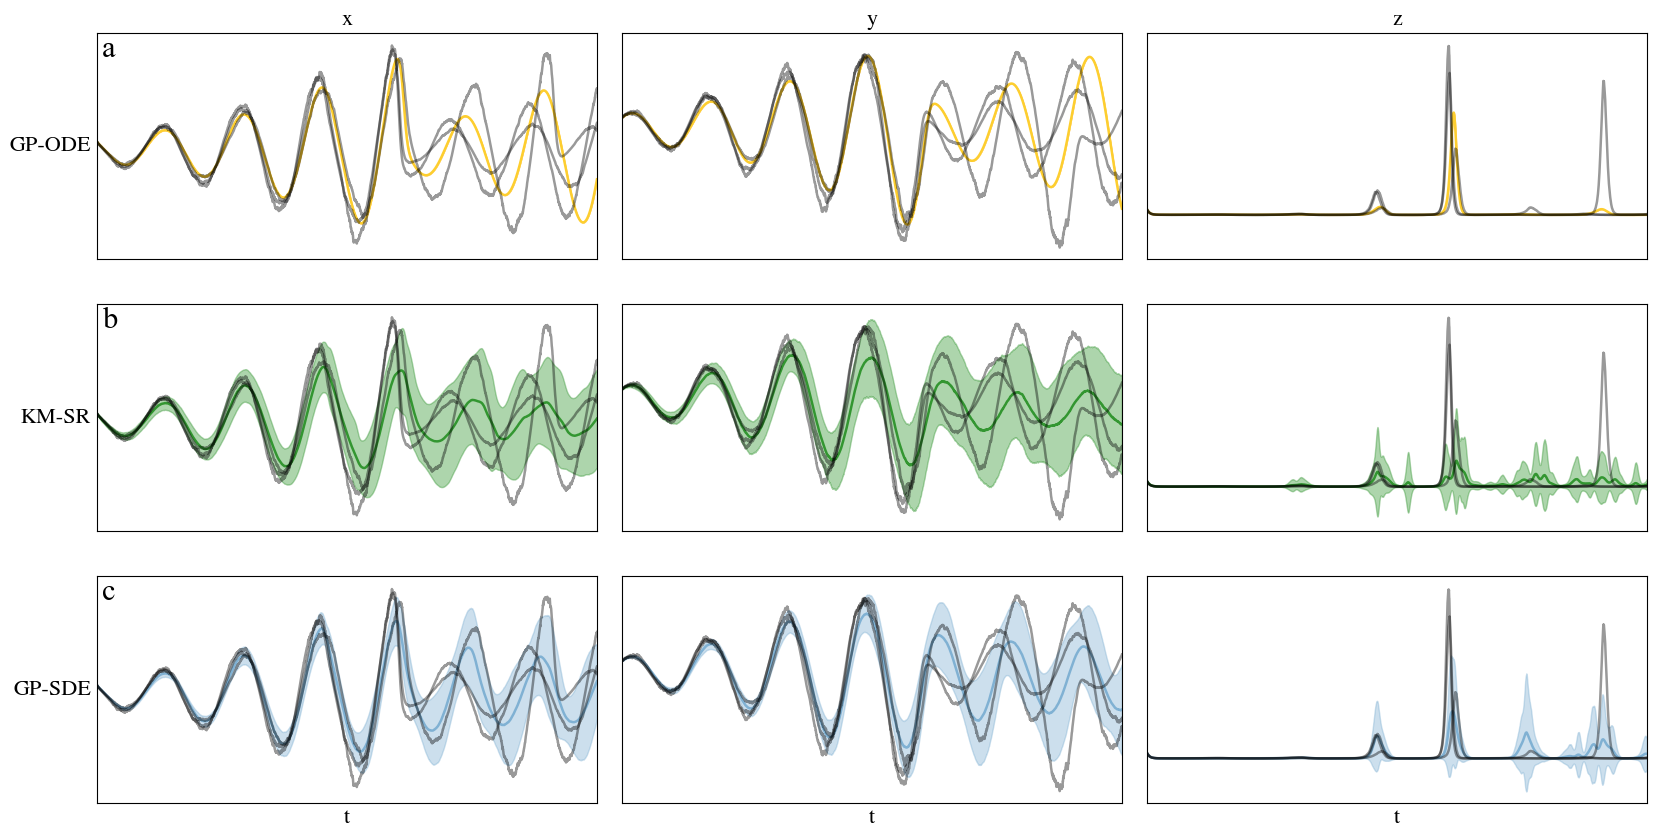

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(20, 10), sharex=True, sharey=False, gridspec_kw={'wspace': 0.05, 'hspace': 0.2})

axes[0, 2].plot(0,0, color="black", alpha=0.4, label="True trajectories", linewidth=2)
# Column 1: GP-ODE
for i in range(3):
    _ax = axes[0, i]
    _ax.set_xlim(0,40)
    _ax.plot(ts, ode_ys[:, :, i].mean(axis=0), color=color_dict["GP-ODE"], linewidth=1.8, label='Mean of prediction')
    _ax.fill_between(ts, 
                      ode_ys[:, :, i].mean(axis=0) - ode_ys[:, :, i].std(axis=0),
                      ode_ys[:, :, i].mean(axis=0) + ode_ys[:, :, i].std(axis=0),
                      color="orange", alpha=0.4, label='±1 std of prediction')
    for j in range(batch_size):
        _ax.plot(ts, true_ys[j, :, i], color="black", alpha=0.4, linewidth=1.8)
    _ax.set_xticks([])
    _ax.set_yticks([])

# axes[0, 2].legend(fontsize=12)

axes[0, 0].set_title(r"x", fontsize=16)

# Column 2: KM-SR
for i in range(3):
    _ax = axes[1, i]
    _ax.set_xlim(0,40)
    _ax.plot(ts, km_ys[:, :, i].mean(axis=0), color=color_dict["KM-SR"], linewidth=1.8, label='Mean')
    _ax.fill_between(ts,
                      km_ys[:, :, i].mean(axis=0) - km_ys[:, :, i].std(axis=0),
                      km_ys[:, :, i].mean(axis=0) + km_ys[:, :, i].std(axis=0),
                      color=color_dict["KM-SR"], alpha=0.4, label='±1 std')
    for j in range(batch_size):
        _ax.plot(ts, true_ys[j, :, i], color="black", alpha=0.4, linewidth=1.8)
    _ax.set_xticks([])
    _ax.set_yticks([])

axes[0, 1].set_title(r"y", fontsize=16)

# Column 3: GP-SDE
for i in range(3):
    _ax = axes[2, i]
    _ax.set_xlim(0,40)
    _ax.plot(ts, sde_ys[:, :, i].mean(axis=0), color=color_dict["GP-SDE"], linewidth=1.8, label='Mean')
    _ax.fill_between(ts,
                      sde_ys[:, :, i].mean(axis=0) - sde_ys[:, :, i].std(axis=0),
                      sde_ys[:, :, i].mean(axis=0) + sde_ys[:, :, i].std(axis=0),
                      color=color_dict["GP-SDE"], alpha=0.4, label='±1 std')
    for j in range(batch_size):
        _ax.plot(ts, true_ys[j, :, i], color="black", alpha=0.4, linewidth=1.8)
    _ax.set_xticks([])
    _ax.set_yticks([])

for i in range(3):
    axes[i,0].set_ylim(-13, 14)
    axes[i,1].set_ylim(-14, 10)
    axes[i,2].set_ylim(-8, 33)

axes[0, 2].set_title(r"z", fontsize=16)

axes[0, 0].set_ylabel("GP-ODE", fontsize=16, rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel("KM-SR", fontsize=16, rotation=0, ha='right', va='center')
axes[2, 0].set_ylabel("GP-SDE", fontsize=16, rotation=0, ha='right', va='center')

axes[0, 0].text(0.4, 11.2, 'a', fontsize=22, font='Times New Roman')
axes[1, 0].text(0.4, 11.2, 'b', fontsize=22, font='Times New Roman')
axes[2, 0].text(0.4, 11.2, 'c', fontsize=22, font='Times New Roman')

axes[2, 0].set_xlabel(r"t", fontsize=16)
axes[2, 1].set_xlabel(r"t", fontsize=16)
axes[2, 2].set_xlabel(r"t", fontsize=16)

plt.tight_layout()
plt.savefig('../figures/rossler_simulation.pdf', dpi=300, bbox_inches='tight')
plt.show()


# Example trajectories

In [12]:
env = VanDerPolOscillator(0.3)
key = jr.PRNGKey(98)
key, subkey = jr.split(key)
batch_size = 1
ts, true_ys = generate_data(subkey, env, 0.01, 20, batch_size)
ts = ts[0]

def simulate_SDE_LV(init_state, ts, process_noise_key):
    def drift(t, x, args):
        dx = env.drift(t, x, args)
        return dx

    def diffusion(t, x, args):
        return env.diffusion(t, x, args)

    brownian_motion = diffrax.UnsafeBrownianPath(shape=(2,), key=process_noise_key, levy_area=diffrax.SpaceTimeLevyArea) #define process noise
    system = diffrax.MultiTerm(diffrax.ODETerm(drift), diffrax.ControlTerm(diffusion, brownian_motion))

    sol = diffrax.diffeqsolve(
        system,
        diffrax.GeneralShARK(),
        t0=ts[0],
        t1=ts[-1],
        dt0=0.001,
        y0=init_state,
        saveat=diffrax.SaveAt(ts=ts),
        adjoint=diffrax.DirectAdjoint(),
        max_steps = 16**5
    )

    ys = sol.ys
    return ys

n_trajectories = 50
noise_keys = jr.split(key, n_trajectories)
sde_ys = jax.vmap(simulate_SDE_LV, in_axes=[None,None,0])(true_ys[0,0], ts, noise_keys)

excess data in 'kern' subtable: 6 bytes


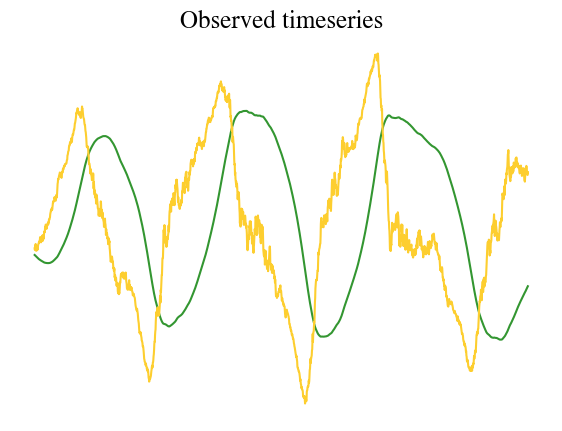

excess data in 'kern' subtable: 6 bytes


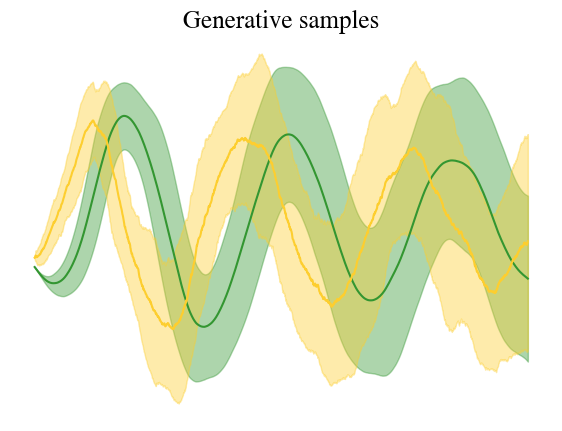

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(ts, true_ys[0,:,0], color=color_dict["KM-SR"])
ax.plot(ts, true_ys[0,:,1], color=color_dict["GP-ODE"])
ax.axis('off')
ax.set_title('Observed timeseries', fontsize=18)
plt.savefig('../figures/true_example.pdf', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(ts, sde_ys[:, :, 0].mean(axis=0), color=color_dict["KM-SR"])
ax.fill_between(ts,
                      sde_ys[:, :, 0].mean(axis=0) - sde_ys[:, :, 0].std(axis=0),
                      sde_ys[:, :, 0].mean(axis=0) + sde_ys[:, :, 0].std(axis=0),
                      color=color_dict["KM-SR"], alpha=0.4)

ax.plot(ts, sde_ys[:,:,1].mean(axis=0), color=color_dict["GP-ODE"])
ax.fill_between(ts,
                      sde_ys[:, :, 1].mean(axis=0) - sde_ys[:, :, 1].std(axis=0),
                      sde_ys[:, :, 1].mean(axis=0) + sde_ys[:, :, 1].std(axis=0),
                      color=color_dict["GP-ODE"], alpha=0.4)
# for i in range(n_trajectories):
    # plt.plot(ts, sde_ys[i, :, 0], color=color_dict["KM-SR"], alpha=0.4)
ax.axis('off')
ax.set_title('Generative samples', fontsize=18)
plt.savefig('../figures/simulation_example.pdf', dpi=300, bbox_inches='tight')
plt.show()

excess data in 'kern' subtable: 6 bytes


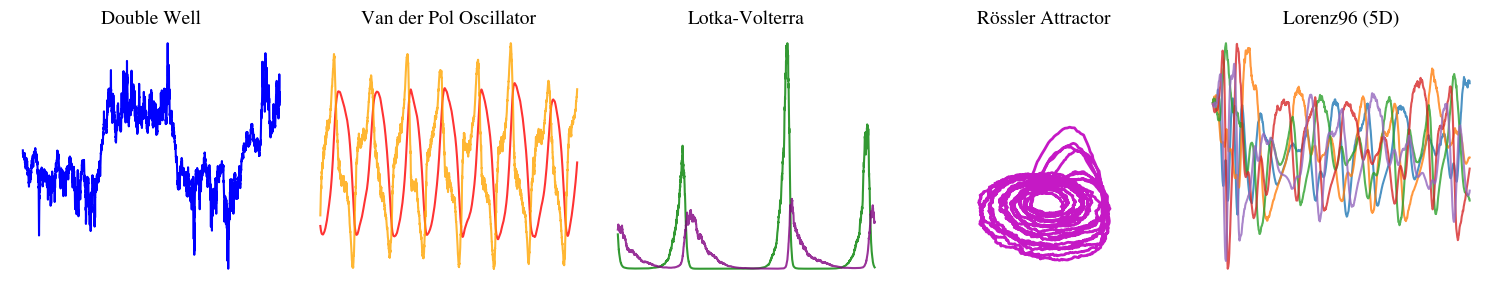

In [16]:
fig = plt.figure(figsize=(18, 3))

key = jr.PRNGKey(98)

# 1. Double Well
ax1 = plt.subplot(1, 6, 1)
env_dw = DoubleWell(0.5, "nonlinear")
key, subkey = jr.split(key)
dt = 0.01
T = 50
ts_dw, ys_dw = generate_data(subkey, env_dw, dt, T, batch_size)
ax1.plot(ts_dw[0], ys_dw[0, :, 0], 'b-', linewidth=1.5)
ax1.set_title('Double Well', fontsize=14, fontweight='bold')
ax1.axis('off')

# 2. Van der Pol Oscillator
ax2 = plt.subplot(1, 6, 2)
env_vdp = VanDerPolOscillator(0.2)
key, subkey = jr.split(key)
ts_vdp, ys_vdp = generate_data(subkey, env_vdp, dt, T, batch_size)
ax2.plot(ts_vdp[0], ys_vdp[0, :, 0], 'r-', linewidth=1.5, alpha=0.8)
ax2.plot(ts_vdp[0], ys_vdp[0, :, 1], 'orange', linewidth=1.5, alpha=0.8)
ax2.set_title('Van der Pol Oscillator', fontsize=14, fontweight='bold')
ax2.axis('off')

# 3. Rossler Attractor
ax3 = plt.subplot(1, 6, 4, projection='3d')
env_ross = RosslerAttractor(0.1)
key, subkey = jr.split(key)
ts_ross, ys_ross = generate_data(subkey, env_ross, dt, T*2, batch_size)
ax3.plot(ys_ross[0, :, 0], ys_ross[0, :, 1], ys_ross[0, :, 2], 'm-', linewidth=2.0, alpha=0.9)
ax3.set_title('Rössler Attractor', fontsize=14, fontweight='bold')
ax3.set_xlim(-12, 12)
ax3.set_ylim(-12, 12)
ax3.set_zlim(0, 50)
ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_zticks([])
ax3.xaxis.pane.fill = False
ax3.yaxis.pane.fill = False
ax3.zaxis.pane.fill = False
ax3.xaxis.pane.set_edgecolor('none')
ax3.yaxis.pane.set_edgecolor('none')
ax3.zaxis.pane.set_edgecolor('none')
ax3.grid(False)
ax3.axis('off')

# 4. Lorenz96
ax4 = plt.subplot(1, 6, 5)
env_l96 = Lorenz96(n_dim=5, process_noise=0.2)
key, subkey = jr.split(key)
ts_l96, ys_l96 = generate_data(subkey, env_l96, dt, 10, batch_size)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
for i in range(5):
    ax4.plot(ts_l96[0], ys_l96[0, :, i], color=colors[i], linewidth=1.5, alpha=0.8)
ax4.set_title('Lorenz96 (5D)', fontsize=14, fontweight='bold')
ax4.axis('off')

# 5. Lotka-Volterra
ax5 = plt.subplot(1, 6, 3)
env_lv = LotkaVolterra(0.2)
key, subkey = jr.split(key)
ts_lv, ys_lv = generate_data(subkey, env_lv, dt, T, batch_size)
ax5.plot(ts_lv[0], ys_lv[0, :, 0], 'g-', linewidth=1.5, alpha=0.8)
ax5.plot(ts_lv[0], ys_lv[0, :, 1], 'purple', linewidth=1.5, alpha=0.8)
ax5.set_title('Lotka-Volterra', fontsize=14, fontweight='bold')
ax5.axis('off')

# 6. Empirical data
# ax6 = plt.subplot(1, 6, 6)
# ax6.set_title('Empirical data', fontsize=14, fontweight='bold')
# ax6.axis('off')

plt.tight_layout()
plt.savefig('../figures/example_trajectories_row.pdf', dpi=300, bbox_inches='tight')
plt.show()


# Stochastic partial differential equations

In [22]:
def plot_spde_snapshots_2D(
    data,
    fit_data,
    trajectory_idx: int = 0,
    n_snapshots: int = 7,
    include_labels: bool = True
):
    """Plot SPDE snapshots. If include_labels=True: top row = truth, bottom row = fitted."""
    # Support both (u, X, Y, times) and (u, X, Y) inputs
    if len(data) == 4:
        u_true, X, Y, times = data
    else:
        u_true, X, Y = data
        times = jnp.arange(u_true.shape[1])

    if len(fit_data) == 4:
        u_fit, X_fit, Y_fit, times_fit = fit_data
    else:
        u_fit, X_fit, Y_fit = fit_data
        times_fit = times

    # Use common range so indices are always valid for both truth and fit
    n_time = min(len(times), len(times_fit))
    time_indices = jnp.linspace(0, n_time - 1, n_snapshots, dtype=int)

    vmin, vmax = -0.2, 0.2
    norm = matplotlib.colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

    if include_labels:
        fig, axes = plt.subplots(
            2,
            n_snapshots,
            figsize=(10, 3),
            gridspec_kw={"wspace": 0.05, "hspace": 0.3}
        )
        if n_snapshots == 1:
            axes = np.array(axes).reshape(2, 1)

        im = None
        for i, t_idx in enumerate(time_indices):
            t_idx = int(t_idx)
            t_true = float(times[t_idx])
            t_fit = float(times_fit[t_idx])

            # Top row: truth
            ax_top = axes[0, i]
            im = ax_top.contourf(X, Y, u_true[trajectory_idx, t_idx], levels=20, cmap="RdBu_r", norm=norm)
            im.set_edgecolors("face")
            ax_top.set_aspect("equal")
            ax_top.set_xticks([])
            if i == 0:
                ax_top.set_ylabel("y", fontsize=16)
                ax_top.set_yticks([0, 4])
            else:
                ax_top.set_ylabel("")
                ax_top.set_yticks([])

            ax_top.tick_params(axis="both", labelsize=12)

            ax_top.text(
                0.03, 0.95, f"t={t_true:.2f}",
                transform=ax_top.transAxes,
                ha="left", va="top", fontsize=12,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5)
            )

            # Bottom row: fitted
            ax_bottom = axes[1, i]
            im = ax_bottom.contourf(X_fit, Y_fit, u_fit[trajectory_idx, t_idx], levels=20, cmap="RdBu_r", norm=norm)
            im.set_edgecolors("face")
            
            if i == 0:
                ax_bottom.set_ylabel("y", fontsize=16)
                ax_bottom.set_xlabel("x", fontsize=16)
                ax_bottom.set_xticks([0, 4])
                ax_bottom.set_yticks([0, 4])
            else:
                ax_bottom.set_ylabel("")
                ax_bottom.set_yticks([])
                ax_bottom.set_xticks([])

            ax_bottom.tick_params(axis="both", labelsize=12)

            ax_bottom.text(
                0.03, 0.95, f"t={t_fit:.2f}",
                transform=ax_bottom.transAxes,
                ha="left", va="top", fontsize=12,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5)
            )

        fig.text(0.5, 1, "True system", ha="center", va="top", fontsize=16)
        fig.text(0.5, 0.55, "GP-SDE", ha="center", va="top", fontsize=16)

        fig.subplots_adjust(right=0.90, wspace=0.08, hspace=0.35, top=0.92)
        cax = fig.add_axes([0.92, 0.16, 0.015, 0.68])
        cbar = fig.colorbar(im, cax=cax, label="u", ticks=[-0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15])
        cbar.ax.tick_params(labelsize=14)
        cbar.set_ticklabels(['-0.15', '-0.10', '-0.05', '0.00', '0.05', '0.10', '0.15'])
        cbar.set_label('u(t,x,y)', fontsize=16)

    else:
        fig, axes = plt.subplots(1, n_snapshots, figsize=(2 * n_snapshots, 3), sharey=True)
        if n_snapshots == 1:
            axes = [axes]

        im = None
        for i, t_idx in enumerate(time_indices):
            t_idx = int(t_idx)
            t_true = float(times[t_idx])

            ax = axes[i]
            im = ax.contourf(X, Y, u_true[trajectory_idx, t_idx], levels=20, cmap="RdBu_r", norm=norm)
            im.set_edgecolors("face")
            ax.set_aspect("equal")
            ax.set_title("")
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis("off")

            ax.text(
                0.03, 0.95, f"t={t_true:.2f}",
                transform=ax.transAxes,
                ha="left", va="top", fontsize=9,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.2)
            )

        plt.tight_layout(pad=0.1)

    plt.savefig(
        f"/Users/sigur.de.vries/myDocuments/figures/SDE_plots/pde_2_{include_labels}.pdf",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

excess data in 'kern' subtable: 6 bytes


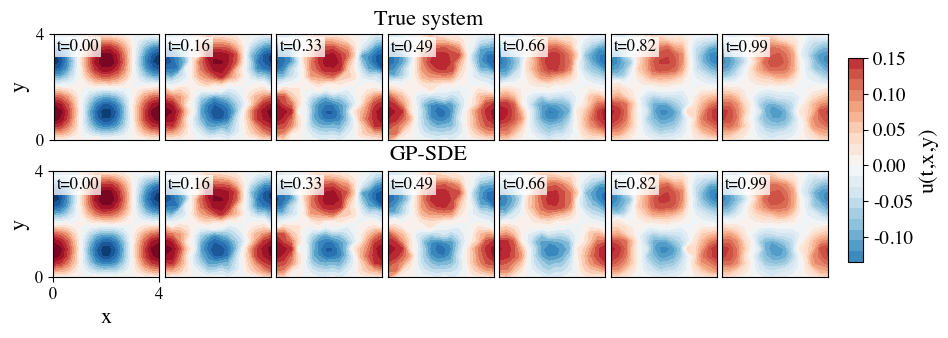

In [23]:
# Initialize 2D solver
nx, ny = 16, 16  # Grid points
Lx, Ly = 4, 4 # Domain size
dt = 0.001  # Time step
batch_size = 1

solver = SPDE_2D(nx, ny, Lx, Ly, dt, true_system=True)
data = solver.generate_spde_data(jr.PRNGKey(0), D=0.1, T=1, n_trajectories=1, save_every=10)
solver = SPDE_2D(nx, ny, Lx, Ly, dt, true_system=False)
fit_data = solver.generate_spde_data(jr.PRNGKey(0), D=0.1, T=1, n_trajectories=1, save_every=10)
plot_spde_snapshots_2D(data, fit_data, 0, include_labels=True)

In [24]:
def plot_spde_snapshots_1D(
    data,
    fit_data,
    trajectory_idx: int = 0,
    include_labels: bool = True,
    cmap: str = "Greens",
    levels: int = 40
):
    """Plot 1D SPDE as heatmaps: top = ground truth, bottom = fit."""
    u_true, X_true, times_true = data
    u_fit, X_fit, times_fit = fit_data

    U_true = u_true[trajectory_idx]
    U_fit = u_fit[trajectory_idx]

    # Ensure shape is (n_t, n_x)
    if U_true.ndim != 2:
        raise ValueError(f"Expected u_true[trajectory_idx] to be 2D, got {U_true.shape}")
    if U_fit.ndim != 2:
        raise ValueError(f"Expected u_fit[trajectory_idx] to be 2D, got {U_fit.shape}")

    if U_true.shape[0] == len(X_true) and U_true.shape[1] == len(times_true):
        U_true = U_true.T
    if U_fit.shape[0] == len(X_fit) and U_fit.shape[1] == len(times_fit):
        U_fit = U_fit.T

    T_true, Xg_true = jnp.meshgrid(times_true, X_true, indexing="xy")
    T_fit, Xg_fit = jnp.meshgrid(times_fit, X_fit, indexing="xy")

    # Shared color range for fair comparison
    vmin = min(float(jnp.min(U_true)), float(jnp.min(U_fit)))
    vmax = max(float(jnp.max(U_true)), float(jnp.max(U_fit)))

    fig, axes = plt.subplots(2, 1, figsize=(10, 3), sharex=False, sharey=False, gridspec_kw={"hspace": 0.3})

    im0 = axes[0].contourf(T_true, Xg_true, U_true.T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    im0.set_edgecolors("face")

    im1 = axes[1].contourf(T_fit, Xg_fit, U_fit.T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    im1.set_edgecolors("face")

    fig.text(0.5, 0.96, "True system", ha="center", va="top", fontsize=16)
    fig.text(0.5, 0.52, "GP-SDE", ha="center", va="top", fontsize=16)

    # Remove x tick labels in top row
    axes[0].tick_params(axis="x", labelbottom=False)

    # Increase tick label font sizes
    axes[0].tick_params(axis="both", labelsize=13)
    axes[1].tick_params(axis="both", labelsize=13)

    if include_labels:
        axes[0].set_ylabel("x", fontsize=15)
        axes[1].set_ylabel("x", fontsize=15)
        axes[1].set_xlabel("t", fontsize=15)

        for ax in axes:
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 20)
            ax.set_xticks([0, 1])
            ax.set_yticks([0, 20])

        cbar = fig.colorbar(im1, ax=axes, label="u(t,x)", fraction=0.025, pad=0.02)
        cbar.ax.tick_params(labelsize=13)
        cbar.set_label("u(t,x)", fontsize=15)
    else:
        for ax in axes:
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis("off")
        fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.02)

    # plt.tight_layout()
    plt.savefig(
        f"/Users/sigur.de.vries/myDocuments/figures/SDE_plots/pde_1_{include_labels}.pdf",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


excess data in 'kern' subtable: 6 bytes


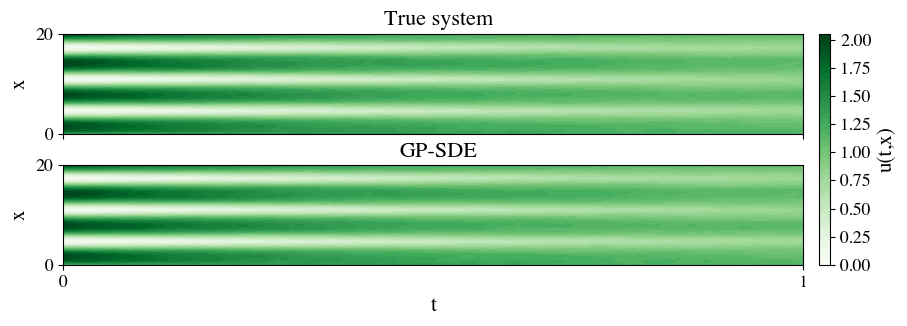

In [25]:
# Initialize 2D solver
nx = 64  # Grid points
Lx = 21 # Domain size
dt = 0.001  # Time step
batch_size = 1

solver = SPDE_1D(nx, Lx, dt, true_system=True)
data = solver.generate_spde_data(jr.PRNGKey(0), D=1.0, T=1.1, n_trajectories=1, save_every=10)
solver = SPDE_1D(nx, Lx, dt, true_system=True)
fit_data = solver.generate_spde_data(jr.PRNGKey(0), D=1.0, T=1.1, n_trajectories=1, save_every=10)
plot_spde_snapshots_1D(data, fit_data, 0, include_labels=True)

# Runtime analysis

excess data in 'kern' subtable: 6 bytes


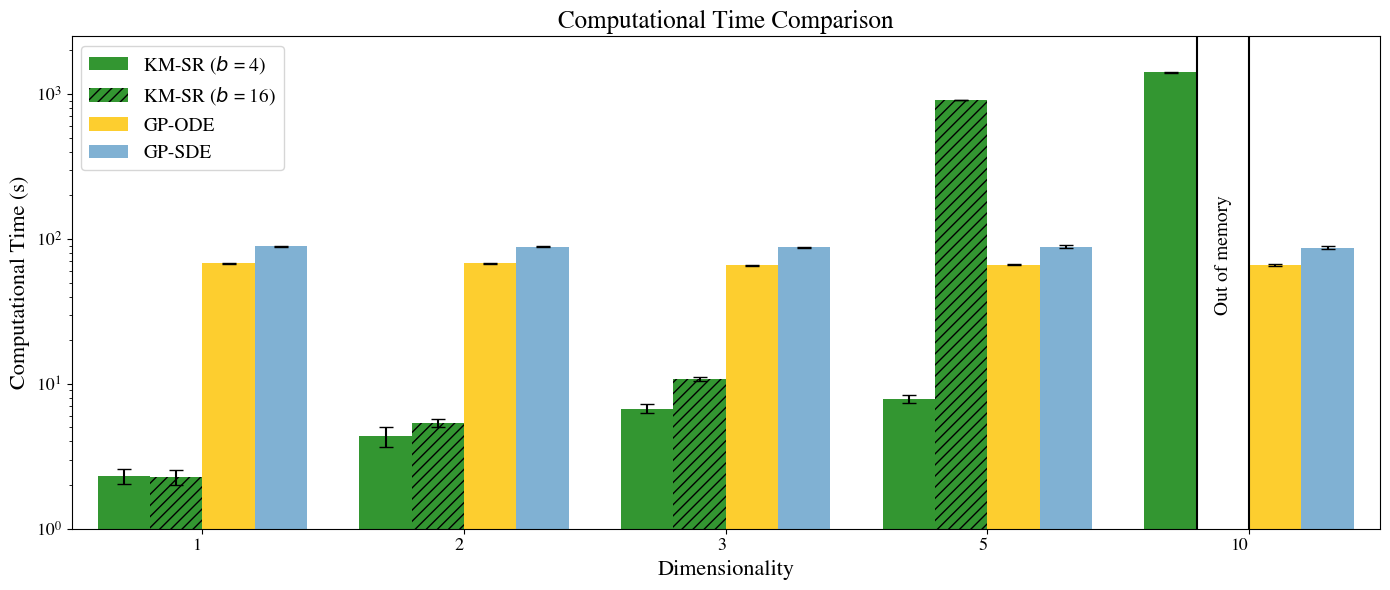

In [17]:
# Load timing data and create a barplot
methods = ['KM-SR', 'GP-ODE', 'GP-SDE']
datasets = ['1', '2', '3', '5', '10']
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 1.0

# Timing data (in seconds)
km4_times = [np.load(f"../data/runtimes/KM_SR_{path}_time.npy") 
            for path in [1, 2, 3, 5, 10]]

km16_times = [np.load(f"../data/runtimes/KM_SR_{path}_16_time.npy") 
            for path in [1, 2, 3, 5]]

gp_ode_times = [np.load(f"../data/runtimes/GP_ODE_{path}_time.npy") 
            for path in [1, 2, 3, 5, 10]]

gp_sde_times = [np.load(f"../data/runtimes/GP_SDE_{path}_time.npy") 
            for path in [1, 2, 3, 5, 10]]

# Calculate means and standard deviations
km4_means = [np.mean(t[1:]) for t in km4_times]
km4_stds = [np.std(t[1:]) for t in km4_times]

km16_means = [np.mean(t[1:]) for t in km16_times]
km16_stds = [np.std(t[1:]) for t in km16_times]

gp_ode_means = [np.mean(t[1:]) for t in gp_ode_times]
gp_ode_stds = [np.std(t[1:]) for t in gp_ode_times]

gp_sde_means = [np.mean(t[1:]) for t in gp_sde_times]
gp_sde_stds = [np.std(t[1:]) for t in gp_sde_times]

x = np.arange(len(datasets))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - (3/2)*width, km4_means, width, label=r'KM-SR ($b$ = 4)', color=color_dict["KM-SR"], yerr=km4_stds, capsize=5)
ax.bar(x[:-1] - width/2, km16_means, width, label=r'KM-SR ($b$ = 16)', color=color_dict["KM-SR"], yerr=km16_stds, capsize=5, hatch='///')
ax.bar(x + width/2, gp_ode_means, width, label='GP-ODE', color=color_dict["GP-ODE"], yerr=gp_ode_stds, capsize=5)
ax.bar(x + (3/2)*width, gp_sde_means, width, label='GP-SDE', color=color_dict["GP-SDE"], yerr=gp_sde_stds, capsize=5)

ax.bar(x[4] - width/2, 2800, width, color='white', edgecolor='black', linewidth=1.5)
ax.text(x[4] - width/2, 30, 'Out of memory', ha='center', va='bottom', fontsize=14, fontweight='bold', rotation=90)

ax.set_xlabel('Dimensionality', fontsize=16)
ax.set_ylabel('Computational Time (s)', fontsize=16)
ax.set_title('Computational Time Comparison', fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(datasets, ha='right', fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.legend(fontsize=14)
ax.set_yscale('log')
ax.set_ylim(1,2499)
ax.set_xlim(-0.5,4.5)

plt.tight_layout()
plt.savefig('../figures/computational_time.pdf', dpi=300, bbox_inches='tight')
plt.show()